# Audio Signal Analysis (Time and Frequency Domain)

This notebook reads `.wav` files located in the directory, plots their time domain graphs, and performs Fast Fourier Transform (FFT) analysis using a Hann window.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

## 1. Time Domain Graph

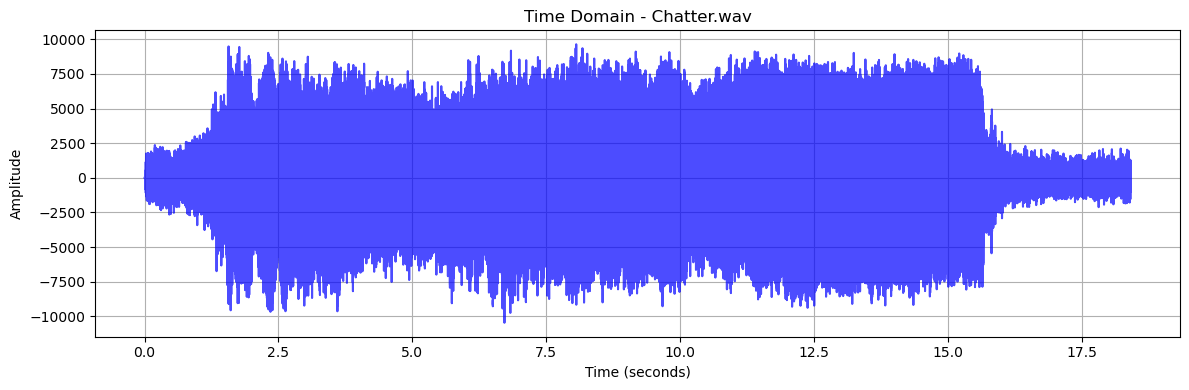

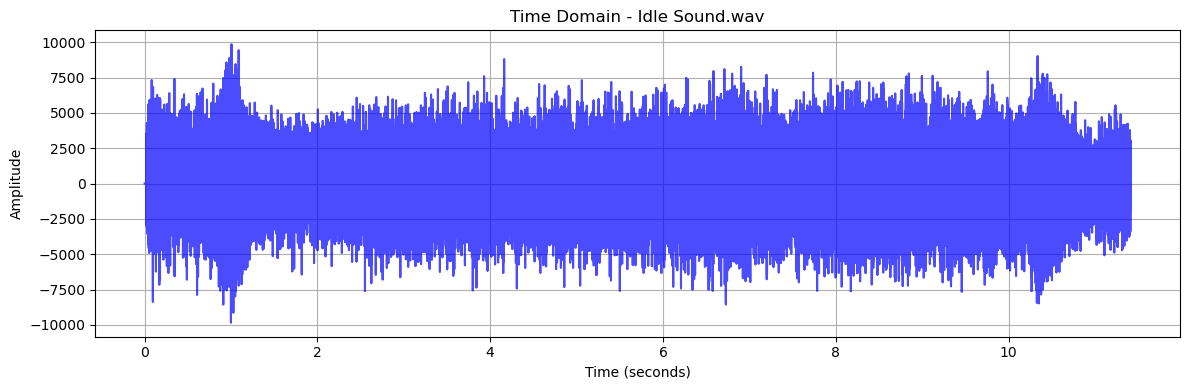

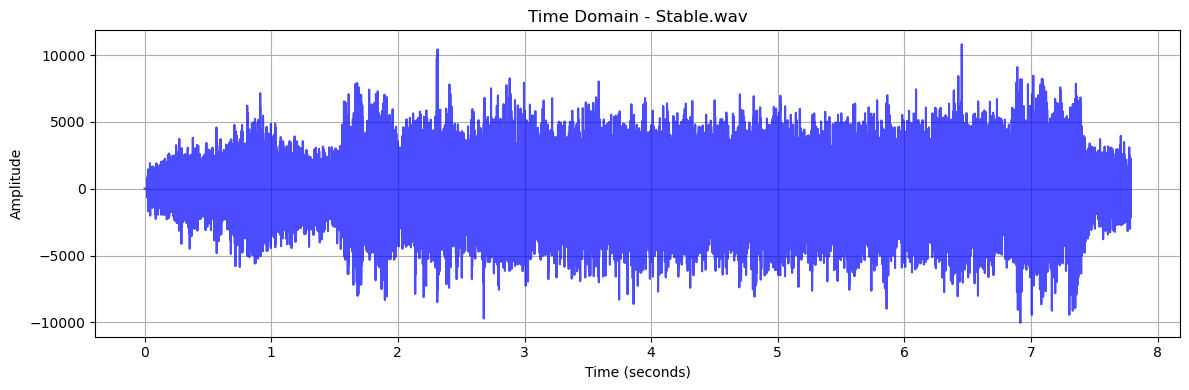

In [44]:
def plot_waveform(filename, title):
    try:
        # Read wav file
        sample_rate, data = wavfile.read(filename)
        
        # If stereo, take only the first channel (channel 0)
        if len(data.shape) > 1:
            data = data[:, 0]
            
        # Create time array (in seconds)
        time = np.linspace(0, len(data) / sample_rate, num=len(data))
        
        # Plotting
        plt.figure(figsize=(12, 4))
        plt.plot(time, data, color='blue', alpha=0.7)
        plt.title(title)
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"An error occurred while processing {filename}: {e}")

# List of wav files to analyze
audio_files = [
    ('Chatter.wav', 'Time Domain - Chatter.wav'),
    ('Idle Sound.wav', 'Time Domain - Idle Sound.wav'),
    ('Stable.wav', 'Time Domain - Stable.wav')
]

# Loop to plot each file
for file, title in audio_files:
    plot_waveform(file, title)


## 2. Fast Fourier Transform (FFT) Analysis with Hann Window

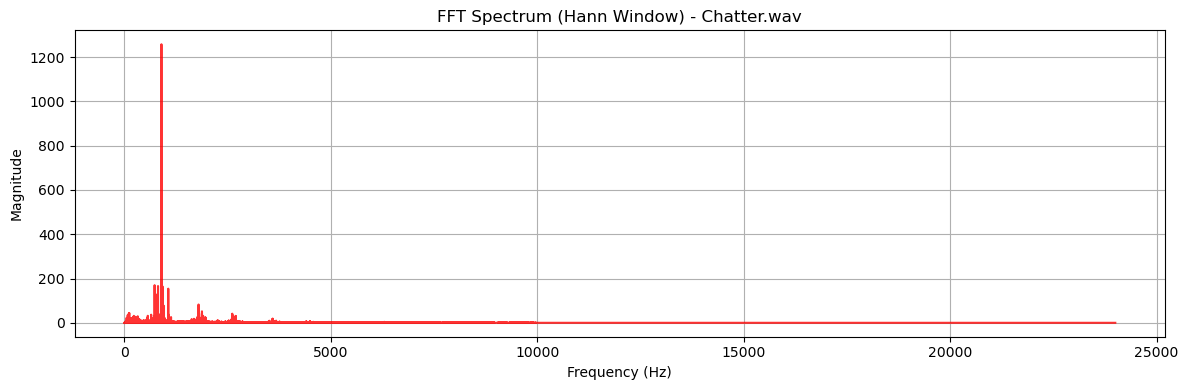

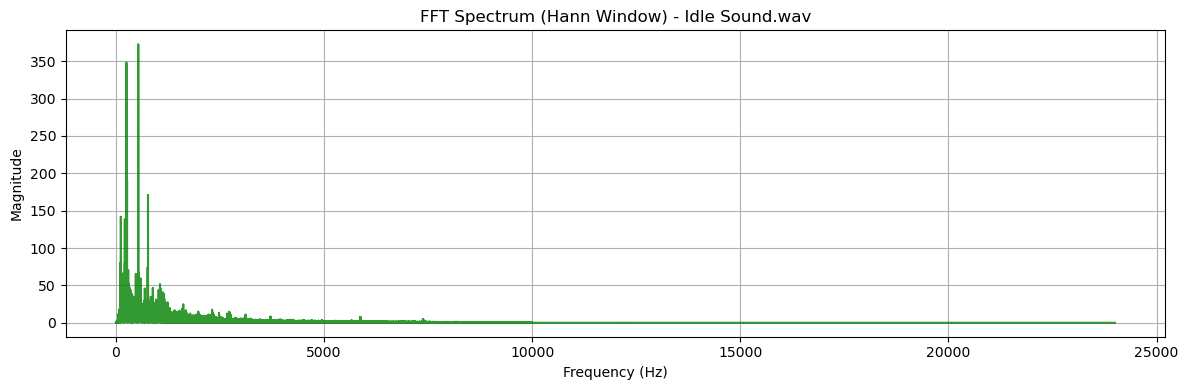

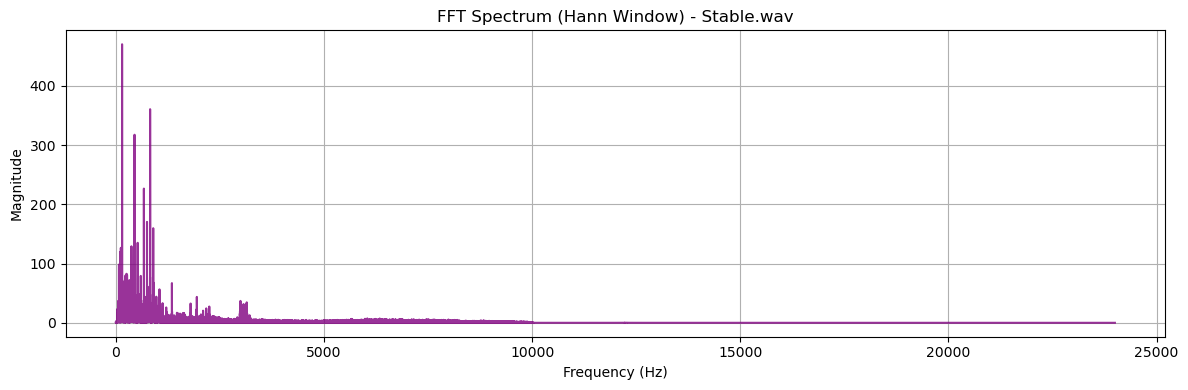

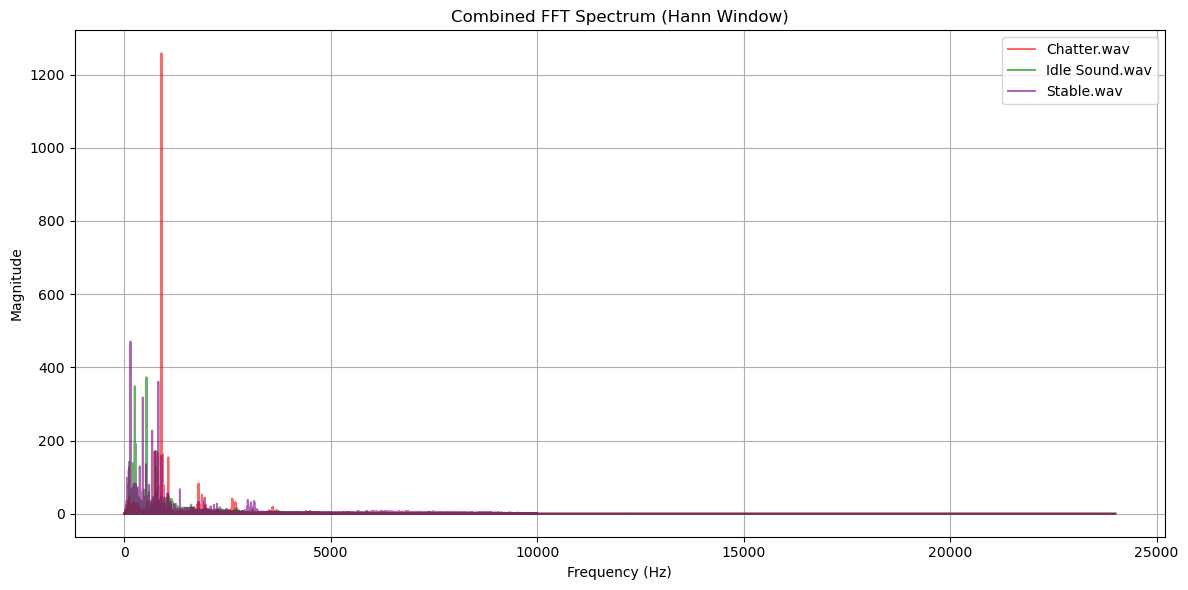

In [45]:
def get_fft_data(filename):
    # Read wav file
    sample_rate, data = wavfile.read(filename)
    if len(data.shape) > 1:
        data = data[:, 0]
        
    # Apply Hann windowing on the audio signal
    N = len(data)
    window = np.hanning(N)
    data_windowed = data * window
    
    # Compute FFT using NumPy
    yf = np.fft.fft(data_windowed)
    xf = np.fft.fftfreq(N, 1 / sample_rate)[:N//2]
    
    # Compute Magnitude
    magnitude = 2.0/N * np.abs(yf[0:N//2])
    
    return xf, magnitude

fft_results = {}
colors = ['red', 'green', 'purple']
files = ['Chatter.wav', 'Idle Sound.wav', 'Stable.wav']

# 2.1 Plot 3 Individual Graphs
for i, file in enumerate(files):
    xf, magnitude = get_fft_data(file)
    fft_results[file] = (xf, magnitude) # Save data for combined plot later
    
    plt.figure(figsize=(12, 4))
    plt.plot(xf, magnitude, color=colors[i], alpha=0.8)
    plt.title(f'FFT Spectrum (Hann Window) - {file}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2.2 Combined Plot (All three files in one graph)
plt.figure(figsize=(12, 6))
for i, file in enumerate(files):
    xf, magnitude = fft_results[file]
    plt.plot(xf, magnitude, label=file, color=colors[i], alpha=0.6)

plt.title('Combined FFT Spectrum (Hann Window)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Chatter Analysis (Comb Filter and Ridge Line Threshold)

Tooth Passing Frequency (TPF): 165.60 Hz


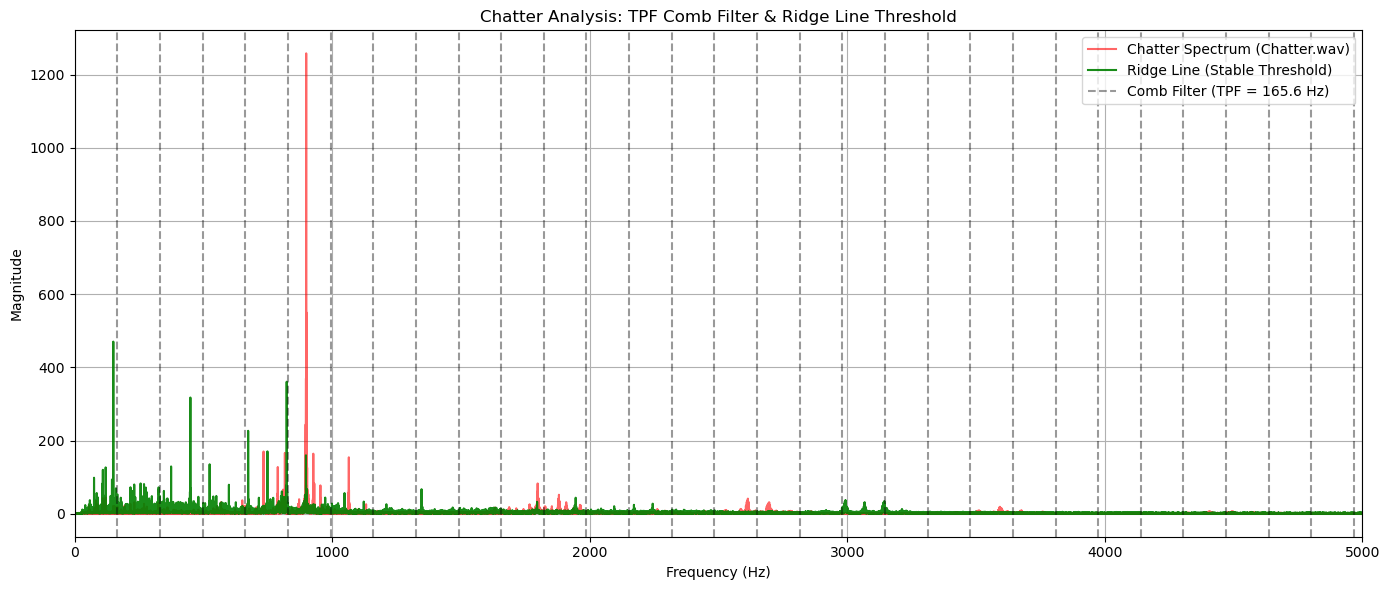

In [46]:
# Machining Parameters
diameter = 63.5  # mm (tool diameter)
rpm = 1656       # chatter RPM
teeth = 6        # number of flutes/teeth
feed_rate = 1915 # mm/min
max_spindle = 6000 # maximum spindle speed

# 1. Calculate Tooth Passing Frequency (TPF)
# TPF (Hz) = (RPM / 60) * number of teeth
tpf = (rpm / 60) * teeth
print(f"Tooth Passing Frequency (TPF): {tpf:.2f} Hz")

# 2. Retrieve FFT data for Chatter and Stable from previous analysis
xf_chatter, mag_chatter = fft_results['Chatter.wav']
xf_stable, mag_stable = fft_results['Stable.wav']

plt.figure(figsize=(14, 6))

# Plot Chatter FFT as the main spectrum for analysis
plt.plot(xf_chatter, mag_chatter, color='red', alpha=0.6, label='Chatter Spectrum (Chatter.wav)')

# Plot Stable FFT as a Ridge Line (Threshold)
plt.plot(xf_stable, mag_stable, color='green', alpha=0.9, linewidth=1.5, label='Ridge Line (Stable Threshold)')

# 3. Create Comb Filter (TPF Harmonics)
# We will plot vertical lines for each TPF harmonic
# Limited up to 5000 Hz for graph clarity
max_freq_plot = 5000 
num_harmonics = int(max_freq_plot / tpf)

for i in range(1, num_harmonics + 1):
    harmonic_freq = i * tpf
    # Add to legend only for the first line
    if i == 1:
        plt.axvline(x=harmonic_freq, color='black', linestyle='--', alpha=0.4, label=f'Comb Filter (TPF = {tpf:.1f} Hz)')
    else:
        plt.axvline(x=harmonic_freq, color='black', linestyle='--', alpha=0.4)

plt.title('Chatter Analysis: TPF Comb Filter & Ridge Line Threshold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, max_freq_plot) # X-axis limit to show harmonics clearly
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Short-Time Fourier Transform (STFT / Spectrogram)

Processing Spectrograms (Time-Frequency Domain)....


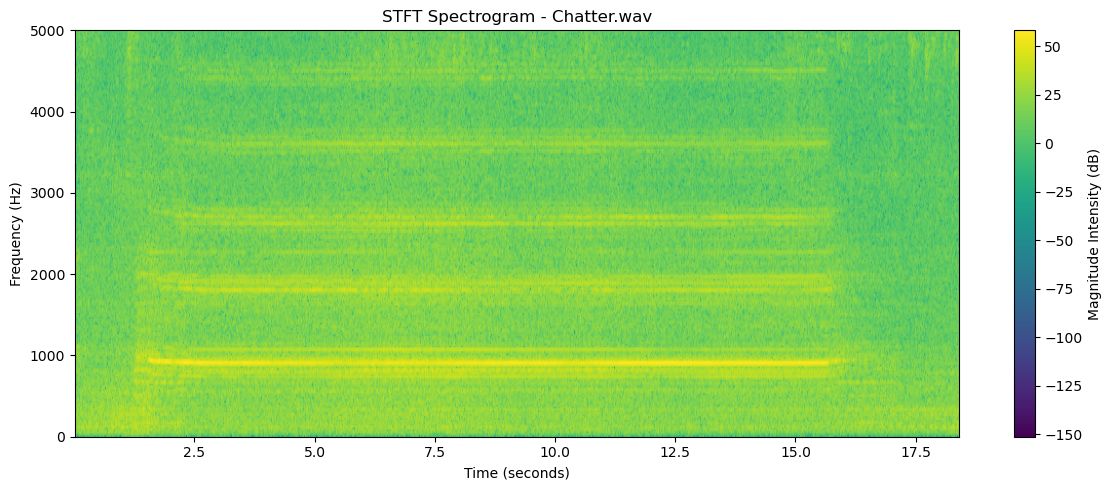

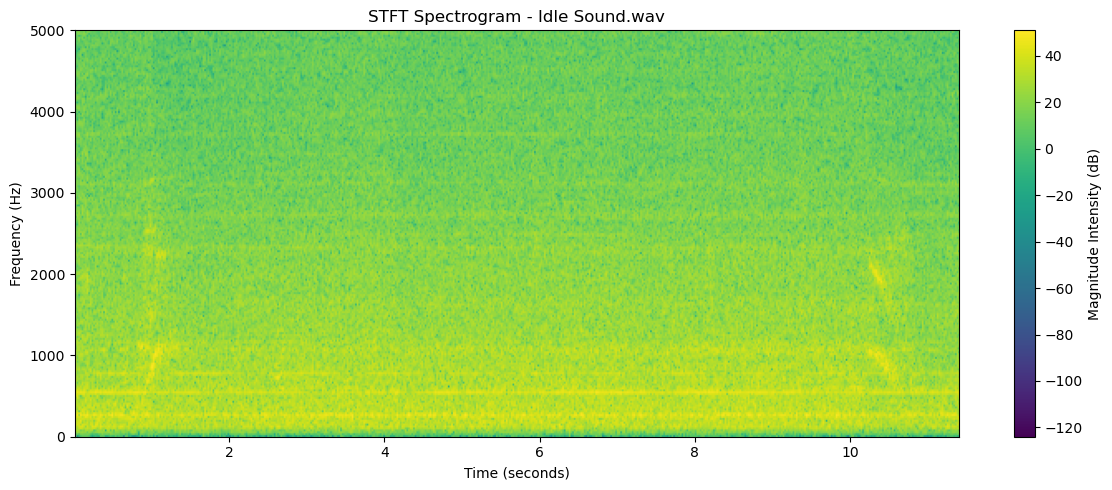

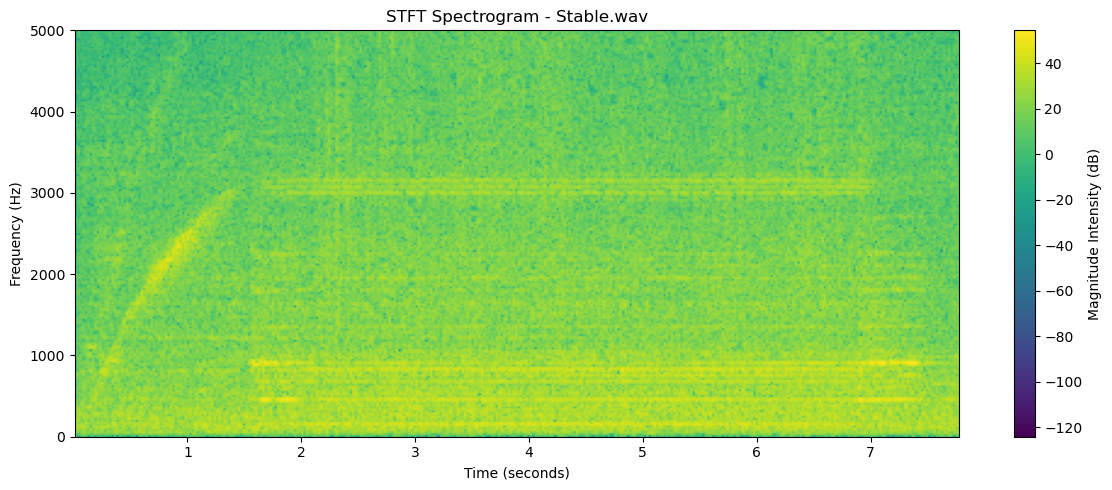

In [47]:
def plot_stft(filename, title):
    # Read wav file
    sample_rate, data = wavfile.read(filename)
    if len(data.shape) > 1:
        data = data[:, 0]
        
    plt.figure(figsize=(12, 5))
    
    # Plot spectrogram using matplotlib
    # NFFT: number of data points used in each STFT block (determines frequency resolution)
    # noverlap: overlap between blocks
    # window: windowing function (Hann)
    Pxx, freqs, bins, im = plt.specgram(
        data, 
        NFFT=2048, 
        Fs=sample_rate, 
        noverlap=1024, 
        window=np.hanning(2048), 
        cmap='viridis'
    )
    
    plt.title(title)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    # Limit max frequency on graph to align with previous FFT graphs (5000 Hz)
    plt.ylim(0, 5000)
    
    # Add color bar indicator
    cbar = plt.colorbar(im)
    cbar.set_label('Magnitude Intensity (dB)')
    
    plt.tight_layout()
    plt.show()

print("Processing Spectrograms (Time-Frequency Domain)....")
for file in files:
    plot_stft(file, f'STFT Spectrogram - {file}')


## 5. Once-Per-Revolution (OPR) Variance Analysis

Based on the methodology from the document _Exploring Once-Per-Revolution Audio Signal Variance as a Chatter Indicator_, chatter can be detected by sampling the audio signal exactly **once per spindle revolution** (Once-Per-Revolution / OPR).

- In **stable** cutting, vibrations are synchronous with the spindle rotation. Therefore, the amplitude values sampled per revolution will tend to cluster at the same value (tight distribution / **low variance**).
- In **chatter** (unstable) cutting, vibrations are asynchronous (not aligned with spindle rotation). This causes the amplitude values sampled per revolution to be randomly scattered (wide distribution / **high variance**).

Below we calculate the variance value ($s^2$) and plot its distribution histogram.

Processing OPR Analysis (RPM = 1656)...


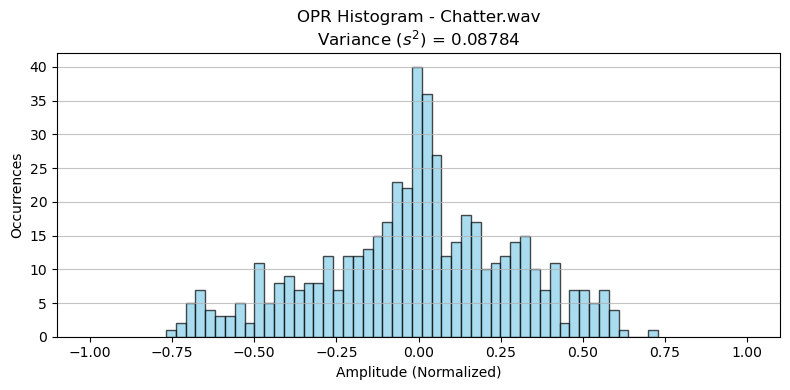

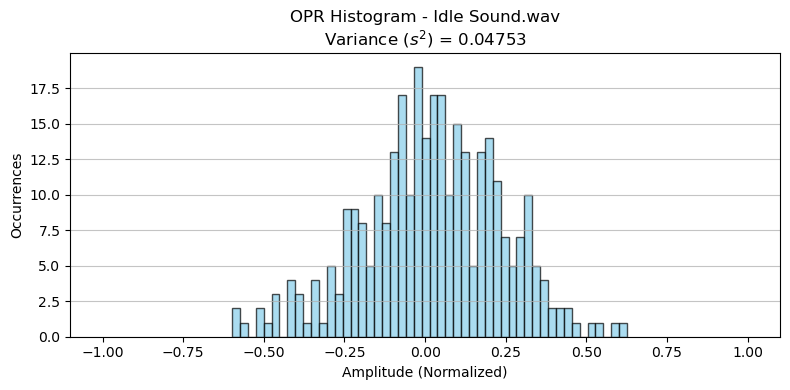

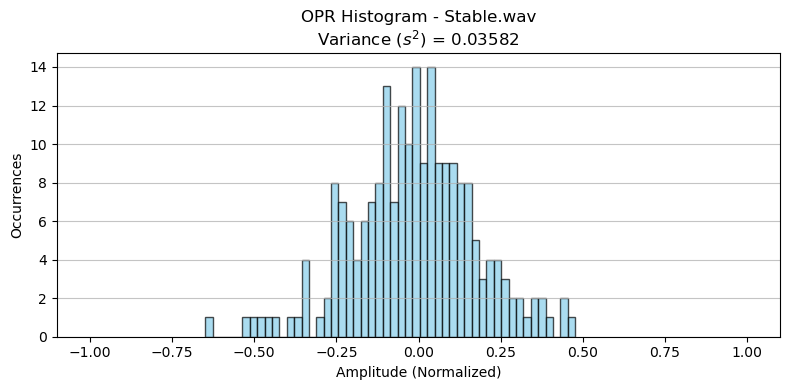


--- OPR Variance Summary ---
- Chatter.wav : 0.08784
- Idle Sound.wav : 0.04753
- Stable.wav : 0.03582


In [48]:
def plot_opr_variance(filename, rpm):
    # Read wav file
    sample_rate, data = wavfile.read(filename)
    if len(data.shape) > 1:
        data = data[:, 0]
        
    # Normalize data to [-1, 1] range to make variance values uniform/comparable
    if np.max(np.abs(data)) > 0:
        data = data / np.max(np.abs(data))
        
    # Calculate number of audio samples in one spindle revolution
    samples_per_rev = sample_rate * 60.0 / rpm
    
    # Extract the exact indices to represent 1x per revolution
    indices = np.arange(0, len(data), samples_per_rev).astype(int)
    indices = indices[indices < len(data)]
    
    # Retrieve amplitude values at the once-per-revolution trigger moments
    opr_samples = data[indices]
    
    # Calculate the variance of these samples
    variance = np.var(opr_samples, ddof=1)
    
    # Plot Histogram
    plt.figure(figsize=(8, 4))
    plt.hist(opr_samples, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'OPR Histogram - {filename}\nVariance ($s^2$) = {variance:.5f}')
    plt.xlabel('Amplitude (Normalized)')
    plt.ylabel('Occurrences')
    plt.grid(axis='y', alpha=0.75)
    plt.xlim(-1.1, 1.1) # Lock limits so the spread is easily comparable visually
    plt.tight_layout()
    plt.show()
    
    return variance

print(f"Processing OPR Analysis (RPM = {rpm})...")
opr_variances = {}
for file in files:
    var_val = plot_opr_variance(file, rpm)
    opr_variances[file] = var_val

print("\n--- OPR Variance Summary ---")
for file, var_val in opr_variances.items():
    print(f"- {file} : {var_val:.5f}")


## 6. Smart RPM and Feed Rate Recommendations
This section intelligently extracts the dominant chatter frequency from `Chatter.wav` by programmatically filtering out valid signals using the **Ridge Line** (filtering out stable background noise) and **Comb Filter** (filtering out synchronous TPF harmonics). The remaining highest energy peak represents the true asynchronous chatter frequency over time.

In [49]:
def calculate_recommendations(chatter_file, stable_file, rpm_chatter, feed_rate_chatter, teeth, actual_stable_rpm):
    # Retrieve FFT data
    xf_chatter, mag_chatter = get_fft_data(chatter_file)
    xf_stable, mag_stable = get_fft_data(stable_file)
    
    tpf = (rpm_chatter / 60) * teeth
    
    # Sort the chatter frequencies by magnitude in descending order
    # Ignore frequencies below 50 Hz to avoid DC noise
    valid_indices = np.where(xf_chatter > 50)[0]
    sorted_indices = valid_indices[np.argsort(mag_chatter[valid_indices])[::-1]]
    
    fc = None
    for idx in sorted_indices:
        freq = xf_chatter[idx]
        mag_c = mag_chatter[idx]
        
        # 1. RIDGE LINE CHECK:
        # Chatter magnitude must be significantly higher than the stable baseline (Ridge Line)
        # We interpolate to find the stable magnitude at this exact frequency
        mag_s = np.interp(freq, xf_stable, mag_stable)
        if mag_c < (mag_s * 1.5):  # Must be at least 50% larger than the stable baseline
            continue
            
        # 2. COMB FILTER CHECK:
        # Ensure the frequency is asynchronous and not just a harmonic of the TPF (Forced Vibration)
        harmonic_ratio = freq / tpf
        nearest_harmonic = round(harmonic_ratio)
        deviation = abs(harmonic_ratio - nearest_harmonic)
        
        # If the deviation is less than 0.05, it means it is a synchronous TPF harmonic (Not Chatter)
        if nearest_harmonic > 0 and deviation < 0.05:
            continue
            
        # 3. STFT / CONSISTENCY LOGIC:
        # By picking the largest remaining peak from the global FFT, 
        # we are inherently picking the frequency with the highest persistent energy over time.
        fc = freq
        break
        
    if fc is None:
        print("Error: No valid chatter frequency found that passes the Ridge Line and Comb Filter criteria.")
        return
    
    print(f"==================================================")
    print(f"SMART CHATTER ANALYSIS & RECOMMENDATIONS")
    print(f"==================================================")
    print(f"1. True Chatter Frequency (fc) = {fc:.2f} Hz")
    print("   -> Passed Ridge Line filter (Above stable threshold)")
    print("   -> Passed Comb Filter (Not a TPF harmonic)")
    
    # Calculate Feed per Tooth during chatter
    fz = feed_rate_chatter / (rpm_chatter * teeth)
    print(f"\n2. Constant Feed per Tooth (fz) = {fz:.5f} mm/tooth")
    
    print("\n3. Stable RPM Recommendations (Based on Stability Lobe):")
    print("---------------------------------------------------------")
    print("Lobe (k) | Recommended RPM | Recommended Feed Rate (mm/min)")
    print("---------------------------------------------------------")
    
    recommended_rpms = []
    for k in range(1, 5):
        n_stable = (60 * fc) / (k * teeth)
        if n_stable > 0:
            new_feed_rate = n_stable * teeth * fz
            recommended_rpms.append(n_stable)
            print(f"   {k}     |     {n_stable:7.2f}     |        {new_feed_rate:8.2f}")
    
    print("\n4. Comparison with User's Actual Stable RPM:")
    print("---------------------------------------------------------")
    print(f"Actual Stable RPM from tests = {actual_stable_rpm} RPM")
    
    closest_rpm = min(recommended_rpms, key=lambda x: abs(x - actual_stable_rpm))
    error = abs(closest_rpm - actual_stable_rpm) / actual_stable_rpm * 100
    
    print(f"Closest Lobe Recommendation  = {closest_rpm:.2f} RPM")
    print(f"Error Margin / Difference    = {error:.2f} %")
    if error < 5:
        print("\nConclusion: The smart filtered chatter frequency ACCURATELY predicts the actual stable RPM!")
    else:
        print("\nConclusion: There is a discrepancy between theory and actual machine performance.")

# Execute the smart calculation function
calculate_recommendations('Chatter.wav', 'Stable.wav', rpm_chatter=1656, feed_rate_chatter=1915, teeth=6, actual_stable_rpm=5955)


SMART CHATTER ANALYSIS & RECOMMENDATIONS
1. True Chatter Frequency (fc) = 898.77 Hz
   -> Passed Ridge Line filter (Above stable threshold)
   -> Passed Comb Filter (Not a TPF harmonic)

2. Constant Feed per Tooth (fz) = 0.19273 mm/tooth

3. Stable RPM Recommendations (Based on Stability Lobe):
---------------------------------------------------------
Lobe (k) | Recommended RPM | Recommended Feed Rate (mm/min)
---------------------------------------------------------
   1     |     8987.72     |        10393.41
   2     |     4493.86     |         5196.71
   3     |     2995.91     |         3464.47
   4     |     2246.93     |         2598.35

4. Comparison with User's Actual Stable RPM:
---------------------------------------------------------
Actual Stable RPM from tests = 5955 RPM
Closest Lobe Recommendation  = 4493.86 RPM
Error Margin / Difference    = 24.54 %

Conclusion: There is a discrepancy between theory and actual machine performance.
